# PGML Workflow applied on FIRETEC simulation

This notebook is prepared for showcasing the PGML workflow applied to the LANL HIGRAD/FIRETEC dataset. Note that the PGML model was developed using the Quic-Fire simulations, specifically for prescribed burns, so there are expected to be significant differences between the model performance and the outputs.

**LANL HIGRAD/FIRETEC**: coupled fire–atmosphere simulation (IEEE SciVis 2022 Contest data, LA-UR-21-30892). The simulation couples HIGRAD (atmospheric hydrodynamics) with FIRETEC (multiphase fire physics), resolving combustion, buoyant plumes, wind, and fuel consumption on a terrain-following grid of 600 × 500 × 61 cells (2 m horizontal spacing, ~1.2 km × 1.0 km domain).

**PGML model**: A deep learning physics-guided model (AfnoNET Seq2Seq), trained on the output of a Quic-Fire simulation run on flat grasslands for prescribed burns. The 4-channel input to the model includes fuel densities, wind components, and the ignition pattern, over a terrain of 296 x 296 cells with 2m horizontal spacing.

To apply the PGML model on the LANL dataset, we note the following differences and preprocessing before applying the PGML model:
1. **Dimensions**: LANL valley fire has 3-dim outputs with surface grid of 600 x 500 cells, and 31-cell height. The PGML model requires a grid of 296 x 296 cells. We choose to crop the relevant portion of the LANL valley fire surface, while keeping the cell size consistent (2 meters).
2. **Surface winds**: Even though the wind conditions are present in the LANL fire, for demonstration purposes, we add 2 channels of static wind components, strictly going northbound.
3. **Ignition type**: The PGML model is specially designed for prescribed burns, where the ignition pattern is known. The LANL fire is run for a wildfire, with an unknown ignition pattern. For demonstration purposes, we synthetically generate an ignition at the south of the fire.

The notebook will handle preprocessing and generate the model outputs based on already trained PGML model, eventually comparing the ground truth and model predictions of the LANL fire in a gif animation.

**References**:
- T. Caglar, J. Jaiswal, S. Azim, Y. Gala, M. Nguyen, & I. Altintas,  *Physics-guided spatiotemporal neural models for fuel density prediction.* Accepted at IGARSS2026, 2026.
- Linn, R. R., Goodrick, S. L., Brambilla, S., Brown, M. J., Middleton, R. S., O'Brien, J. J., & Hiers, J. K., *QUIC-fire: A fast-running simulation tool for prescribed fire planning.* Environmental Modelling & Software, 125, 104616, 2020.
- JJ Sharples, AE Kiss, J Raposo, DX Viegas, and CC Simpson. Pyrogenic vorticity from windward and lee slope fires. *Int. Congr. Model. Simul., Gold Coast, Aust.* 29 Nov.–4 Dec, pages 291–97, 2015.

***Note***
This notebook is made to work on NDP. Please contact T. Caglar for any questions/comments


In [3]:
# Install dependencies

%pip install numpy torch einops scikit-learn matplotlib cmocean transformers ipywidgets

  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
  Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl.metadata (20 kB)
Using cached ipywidgets-8.1.8-py3-none-any.whl (139 kB)
Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl (914 kB)
Note: you may need to restart the kernel to use updated packages.


## Load dependencies

In [5]:
import os
import torch

from FourCastNet.networks.afnonet_wf import AFNONet_Seq2Seq
from common_utils.config import Config

from common_utils.dataloader import create_datasets_lite, create_dataloaders

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import io

from IPython.display import Image as IPythonImage

from tqdm import tqdm

from matplotlib.colors import LinearSegmentedColormap

# Colormap 
black_white_green = LinearSegmentedColormap.from_list(
    'black_white_green',
    ['black', 'white', 'green']
)

# 0. config
args_config = 'data_lanl_fire/config.yaml'
config = Config(filepath=args_config, override_from_env=False, override_from_args=False)
config.in_channels = 4

# 1. Instantiate the model structure
model = AFNONet_Seq2Seq(
    img_size=(config.image_size, config.image_size), patch_size=(config.patch_size, config.patch_size),
    in_chans=config.in_channels, out_chans=config.out_channels,
    context_len=config.context_len, temporal_patch_size=config.temporal_patch_size,
    embed_dim=config.embed_dim, depth=config.depth, num_blocks=config.num_blocks
)


# 2. Load your weights
model_path = 'data_lanl_fire/best_model.pth'
weights = torch.load(model_path, map_location=torch.device('cpu'))
model.load_state_dict(weights['state_dict'])

<All keys matched successfully>

## Generate gif for the predictions

In [4]:
def images_to_gif(images, output_path, duration=200, cmap='viridis', vmin=None, vmax=None, start_index=0):
    """
    Convert a list of 2D numpy arrays to an animated GIF.
    
    Args:
        images: list of 2D numpy arrays
        output_path: path to save the GIF (e.g., 'output.gif')
        duration: milliseconds per frame
        cmap: matplotlib colormap
        vmin/vmax: colormap value range (uses global min/max if None)
    """
    frames = []
    vmin = vmin if vmin is not None else min(img.min() for img in images)
    vmax = vmax if vmax is not None else max(img.max() for img in images)

    for i, img in tqdm(enumerate(images), total=len(images), desc="Creating GIF frames"):
        fig, ax = plt.subplots()
        ax.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(f'Time step {i + start_index}')
        ax.axis('off')

        buf = io.BytesIO()
        plt.savefig(buf, format='png', bbox_inches='tight', pad_inches=0)
        plt.close(fig)
        buf.seek(0)
        frames.append(Image.open(buf).convert('RGBA'))

    frames[0].save(
        output_path,
        save_all=True,
        append_images=frames[1:],
        duration=duration,
        loop=0  # 0 = loop forever
    )
    print(f"Saved GIF to {output_path}")

### 1. Crop the LANL Fire

Left is the 296 x 296 cropped 2d surface. Right imasge is the original size with 500 x 600 surface. Note that the surface data `output.{time}.npy` is already extracted from the raw dataset, and the `.npy` includes only the 500 x 600 surface as read from the variable `rhof_1`.

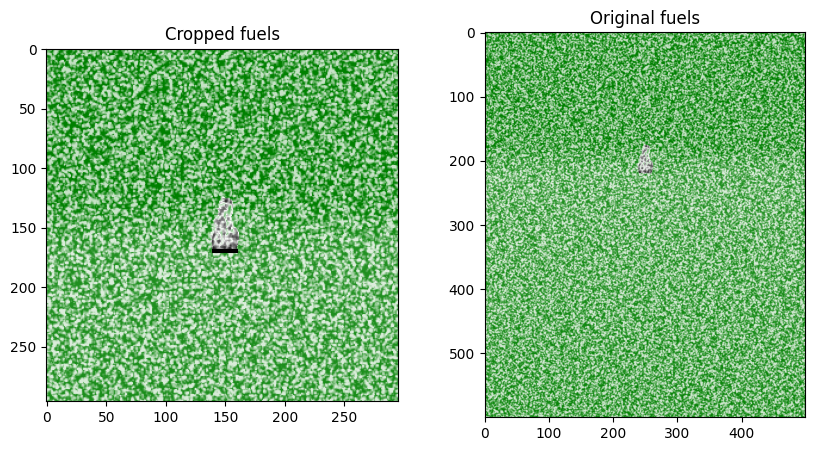

In [10]:
# Generate time-lapse for the firetec dataset.

fig, ax = plt.subplots(1,2, figsize=(10,5))

folder = 'data_lanl_fire/firetec-data-test/'
time = '12000'

firetec_fuels = np.load(os.path.join(folder, f'output.{time}.npy'))
# firetec_fuels.resize(296,296)

img = Image.fromarray(firetec_fuels)
# ax[0].imshow(np.array(img.resize((296,296))), cmap=black_white_green, vmin=0, vmax=1)
# ax[0].set_title('Resized fuels')
ax[0].imshow(firetec_fuels[50:(50+296), 100:(100+296)], cmap=black_white_green, vmin=0, vmax=1)
ax[0].set_title('Cropped fuels')


ax[1].imshow(firetec_fuels, cmap=black_white_green, vmin=0, vmax=1)
ax[1].set_title('Original fuels')

ax[0].plot([140,160], [170,170], 'k-')
ax[0].plot([140,160], [169,169], 'k-')


In [18]:
firetec_fuels_cropped = []
for t in tqdm(range(1000,64000,1000), desc="Processing firetec fuels"):
    firetec_fuels = np.load(os.path.join(folder, f'output.{t}.npy'))
    firetec_fuels = firetec_fuels[50:(50+296), 100:(100+296)]
    firetec_fuels_cropped.append(firetec_fuels)

# Save the predictions as a GIF
firetec_fuels_cropped_path = 'firetec_fuels_cropped.gif'
images_to_gif(firetec_fuels_cropped, firetec_fuels_cropped_path, duration=200, vmin=0, vmax=1, cmap=black_white_green, start_index=0)

IPythonImage(url=firetec_fuels_cropped_path)

Creating GIF frames: 100%|██████████| 63/63 [00:18<00:00,  3.48it/s]


Saved GIF to firetec_fuels_cropped.gif


### Generate the channels for the LANL Fire

Text(0.5, 1.0, 'Source map')

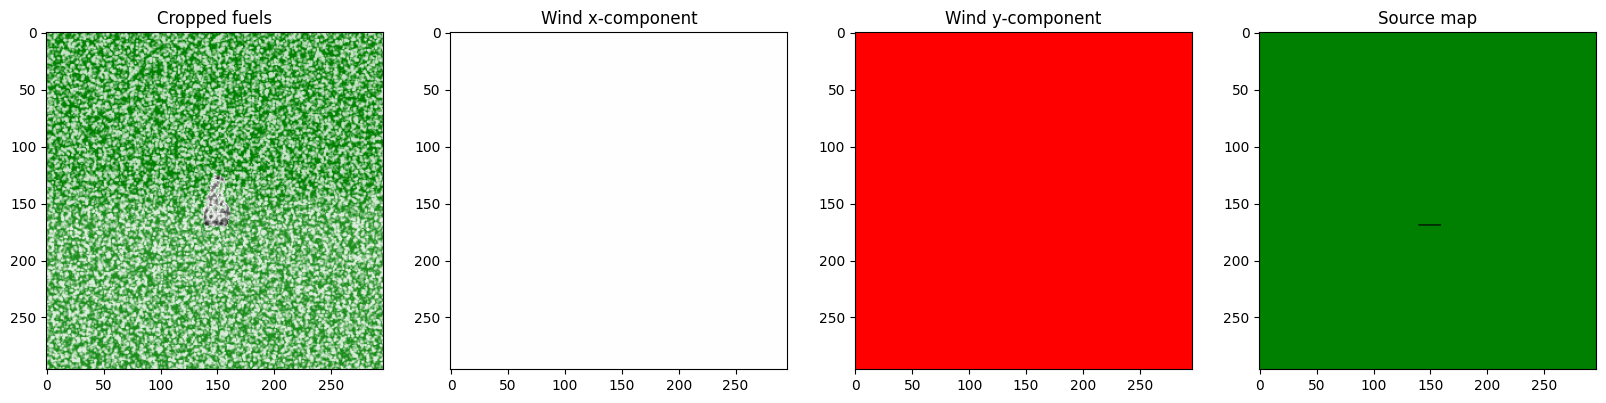

In [19]:

fig, ax = plt.subplots(1,4, figsize=(20,5))

folder = 'data_lanl_fire/firetec-data-test/'
time = '12000'

firetec_fuels = np.load(os.path.join(folder, f'output.{time}.npy'))

img = Image.fromarray(firetec_fuels)
# ax[0].imshow(np.array(img.resize((296,296))), cmap=black_white_green, vmin=0, vmax=1)
# ax[0].set_title('Resized fuels')
ax[0].imshow(firetec_fuels[50:(50+296), 100:(100+296)], cmap=black_white_green, vmin=0, vmax=1)
ax[0].set_title('Cropped fuels')

windcos = np.zeros((296,296))
ax[1].imshow(windcos, cmap='bwr', vmin=-1, vmax=1)
ax[1].set_title('Wind x-component')

windsin = np.ones((296,296))
ax[2].imshow(windsin, cmap='bwr', vmin=-1, vmax=1)
ax[2].set_title('Wind y-component')

source_map = np.ones((296,296))
# source_map = firetec_fuels[50:(50+296), 100:(100+296)].copy()
source_map[169, 140:160] = 0
ax[3].imshow(source_map, cmap=black_white_green, vmin=0, vmax=1)
ax[3].set_title('Source map')

### Setting LANL Fire inputs

In [20]:
firetec_inputs = np.zeros((64,4,296,296))
for i, time in tqdm(enumerate(range(1000,64000,1000)), desc="Processing firetec inputs", total=64):
    firetec_fuels = np.load(os.path.join(folder, f'output.{time}.npy'))
    firetec_fuels = firetec_fuels[50:(50+296), 100:(100+296)]
    firetec_inputs[i,0,:,:] = firetec_fuels
    firetec_inputs[i,1,:,:] = windcos
    firetec_inputs[i,2,:,:] = windsin
    firetec_inputs[i,3,:,:] = source_map

Processing firetec inputs:  98%|█████████▊| 63/64 [00:00<00:00, 708.13it/s]


### Applying PGML model to LANL Fire

In [21]:
firetec_predictions = []
model.eval()
with torch.no_grad():
    firetec_inputs_tensor = torch.from_numpy(firetec_inputs).float()
    for t in tqdm(range(6,64), desc="Calculating firetec predictions"):
        input_t = firetec_inputs_tensor[t-6:t,:,:,:].unsqueeze(0)
        pred_t = model(input_t)
        firetec_predictions.append(pred_t[0][0][0].numpy())

Calculating firetec predictions: 100%|██████████| 58/58 [00:25<00:00,  2.28it/s]


In [22]:
# Save the predictions as a GIF
firetec_predictions_path = 'firetec_predictions.gif'
images_to_gif(firetec_predictions, firetec_predictions_path, duration=200, vmin=0, vmax=1, cmap=black_white_green, start_index=6)

IPythonImage(url=firetec_predictions_path)

Creating GIF frames: 100%|██████████| 58/58 [00:09<00:00,  5.86it/s]


Saved GIF to firetec_predictions.gif


In [28]:
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import matplotlib as mpl
import io

def combine_gifs_side_by_side(gifpath1, gifpath2, outputpath, duration=200, loop=0, gap=10,
                               cmap=None, vmin=0, vmax=1,
                               title1='original', title2='predicted', title_height=30,
                               skip1=0, skip2=0):

    gif1 = Image.open(gifpath1)
    gif2 = Image.open(gifpath2)

    # Skip initial frames
    for _ in range(skip1):
        gif1.seek(gif1.tell() + 1)
    for _ in range(skip2):
        gif2.seek(gif2.tell() + 1)

    # Pre-render colorbar once (same for all frames)
    cb_img = None
    if cmap is not None:
        colorbar_width = 60
        fig, ax = plt.subplots(figsize=(0.6, 3))
        norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
        mpl.colorbar.ColorbarBase(ax, cmap=cmap, norm=norm, orientation='vertical')
        buf = io.BytesIO()
        plt.savefig(buf, format='png', bbox_inches='tight', pad_inches=0.05, dpi=100)
        plt.close(fig)
        buf.seek(0)
        cb_img = Image.open(buf).convert('RGBA')

    try:
        font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", size=16)
    except Exception:
        font = ImageFont.load_default()

    frames = []
    try:
        while True:
            f1 = gif1.copy().convert('RGBA')
            f2 = gif2.copy().convert('RGBA')

            total_width = f1.width + gap + f2.width
            total_height = title_height + f1.height
            if cb_img is not None:
                cb_resized = cb_img.resize((colorbar_width, f1.height), Image.LANCZOS)
                total_width += gap + colorbar_width

            combined = Image.new('RGBA', (total_width, total_height), (255, 255, 255, 255))
            draw = ImageDraw.Draw(combined)

            # Draw titles
            for text, x_center in [(title1, f1.width // 2), (title2, f1.width + gap + f2.width // 2)]:
                bbox = draw.textbbox((0, 0), text, font=font)
                text_w = bbox[2] - bbox[0]
                draw.text((x_center - text_w // 2, (title_height - (bbox[3] - bbox[1])) // 2),
                          text, fill=(0, 0, 0, 255), font=font)

            # Paste frames below titles
            combined.paste(f1, (0, title_height))
            combined.paste(f2, (f1.width + gap, title_height))

            if cb_img is not None:
                combined.paste(cb_resized, (f1.width + gap + f2.width + gap, title_height))

            frames.append(combined)

            gif1.seek(gif1.tell() + 1)
            gif2.seek(gif2.tell() + 1)
    except EOFError:
        pass

    frames[0].save(
        outputpath,
        save_all=True,
        append_images=frames[1:],
        duration=duration,
        loop=loop
    )
    print(f"Saved combined GIF to {outputpath}")

In [32]:
firetec_comparison_path = 'firetec_comparison.gif'
combine_gifs_side_by_side(
    firetec_fuels_cropped_path, firetec_predictions_path, firetec_comparison_path,
    duration=200, loop=0, gap=10, cmap=black_white_green, vmin=0, vmax=1,
    title1='Ground truth', title2='Predictions', skip1=6
)

IPythonImage(url = firetec_comparison_path)

Saved combined GIF to firetec_comparison.gif
